## 📥 Loading the Dataset

We are using the KDD dataset, which contains network traffic data.

Each row represents a connection and includes features like:
- protocol type
- bytes transferred
- error rates

The goal is to classify each connection as:
- Normal
- Attack

In [1]:
import pandas as pd

data = pd.read_csv("KDDTrain+.txt", header=None)
print(data.head())

   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]


## 🏷️ Assigning Column Names

The dataset does not include column headers, so we manually assign them.

This helps in:
- Understanding each feature
- Performing analysis and preprocessing

In [2]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

data.columns = columns

## 🔍 Understanding the Data

We check:
- Number of rows and columns
- Distribution of labels

This helps us understand:
- Dataset size
- Class imbalance (important for ML models)

In [3]:
print(data.shape)
print(data["label"].value_counts())

(125973, 43)
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


## 🧹 Removing Unnecessary Features

The 'difficulty' column is not needed for prediction, so we remove it.

Keeping only relevant features improves model performance.

In [4]:
data = data.drop("difficulty", axis=1)

## 🔄 Simplifying Labels

The dataset contains multiple attack types.

We convert them into:
- "normal"
- "attack"

This simplifies the problem into a binary classification task.

In [5]:
data["label"] = data["label"].apply(lambda x: "normal" if x == "normal" else "attack")

In [6]:
print(data["label"].value_counts())

label
normal    67343
attack    58630
Name: count, dtype: int64


## 🔢 Encoding Categorical Features

Machine Learning models cannot work with text data.

We convert categorical values like:
- protocol_type
- service
- flag

into numerical values using Label Encoding.

In [27]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in ["protocol_type", "service", "flag"]:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

## ✂️ Splitting the Dataset

We split the data into:
- Training set (80%)
- Testing set (20%)

Training data is used to train the model.  
Testing data is used to evaluate performance.

In [28]:
from sklearn.model_selection import train_test_split

X = data.drop("label", axis=1)
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🤖 Model Selection

We use a Random Forest Classifier.

Why?
- Works well for classification
- Handles large datasets
- Reduces overfitting using multiple decision trees

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

## 📊 Evaluating Model Performance

We evaluate the model using:
- Accuracy → overall correctness
- Precision → how many predicted attacks were correct
- Recall → how many actual attacks were detected

Recall is very important in cybersecurity because missing an attack is dangerous.

In [31]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9986505258979956
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11773
      normal       1.00      1.00      1.00     13422

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [32]:
def detect_threat(input_data):
    prediction = model.predict([input_data])
    if prediction[0] == "attack":
        return "⚠️ Threat detected!"
    else:
        return "Safe"

<Axes: xlabel='label', ylabel='count'>

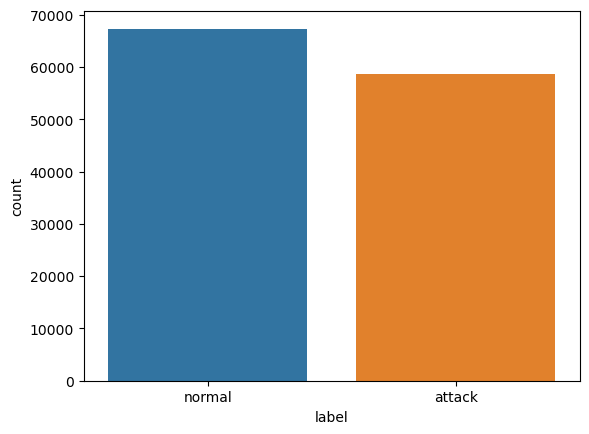

In [33]:
import seaborn as sns
sns.countplot(x="label", data=data)

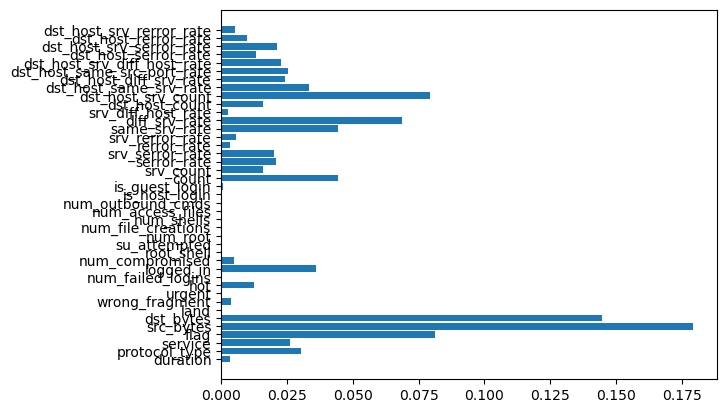

In [34]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
plt.barh(X.columns, importances)
plt.show()

## 🔍 Confusion Matrix

The confusion matrix shows:
- True Positives → correct attack detection
- False Negatives → missed attacks
- False Positives → false alarms

This helps us understand model weaknesses.

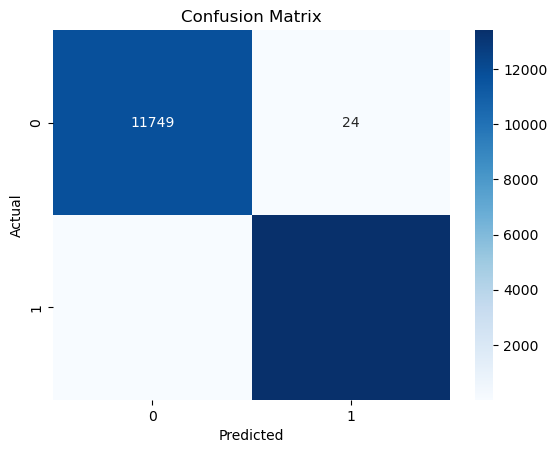

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## ⚠️ Recall Score (Important Metric)

Recall tells us:
Out of all actual attacks, how many did we correctly detect?

High recall is critical in intrusion detection systems.

In [36]:
from sklearn.metrics import recall_score

print("Recall:", recall_score(y_test, y_pred, pos_label="attack"))

Recall: 0.9979614371867833


## 📈 Feature Importance

Random Forest provides feature importance scores.

This tells us:
- Which features are most useful in detecting attacks
- What patterns the model relies on

In [37]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df.head(10))

                   feature  importance
4                src_bytes    0.179377
5                dst_bytes    0.144475
3                     flag    0.081037
32      dst_host_srv_count    0.079239
29           diff_srv_rate    0.068581
22                   count    0.044514
28           same_srv_rate    0.044251
11               logged_in    0.035986
33  dst_host_same_srv_rate    0.033490
1            protocol_type    0.030430


## 🔮 Testing on Sample Data

We randomly select a sample from test data.

This simulates how the model behaves on unseen data.

In [38]:
import random

sample = X_test.sample(1)

result = model.predict(sample)

print("Input data:\n", sample)
print("Prediction:", result[0])

Input data:
         duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
105791         0              1       49     5          0          0     0   

        wrong_fragment  urgent  hot  ...  dst_host_count  dst_host_srv_count  \
105791               0       0    0  ...             255                   4   

        dst_host_same_srv_rate  dst_host_diff_srv_rate  \
105791                    0.02                    0.07   

        dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  \
105791                          0.0                          0.0   

        dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate  \
105791                   1.0                       1.0                   0.0   

        dst_host_srv_rerror_rate  
105791                       0.0  

[1 rows x 41 columns]
Prediction: attack


In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9986505258979956

Classification Report:
               precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11773
      normal       1.00      1.00      1.00     13422

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195


Confusion Matrix:
 [[11749    24]
 [   10 13412]]


In [40]:
samples = X_test.sample(5)

predictions = model.predict(samples)

print(samples)
print("Predictions:", predictions)

       duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
62454         0              1       24     9        242        691     0   
82117         0              1       24     9        260       1055     0   
61555         0              1       24     9        200        294     0   
12074         0              1       49     1          0          0     0   
47748         0              1       24     9        217        617     0   

       wrong_fragment  urgent  hot  ...  dst_host_count  dst_host_srv_count  \
62454               0       0    0  ...              29                 255   
82117               0       0    0  ...             121                 255   
61555               0       0    0  ...             255                 255   
12074               0       0    0  ...              69                  14   
47748               0       0    0  ...             255                 255   

       dst_host_same_srv_rate  dst_host_diff_srv_rate  \
62454

## 📊 Prediction Confidence

Instead of just predicting attack or normal,
we also check probability.

This gives confidence level of prediction.

In [41]:
probs = model.predict_proba(sample)

print("Prediction:", result[0])
print("Confidence:", max(probs[0]))

Prediction: attack
Confidence: 1.0


## 💾 Saving the Model

We save the trained model using joblib.

This allows us to reuse the model without retraining.

In [42]:
import joblib

joblib.dump(model, "intrusion_detection_model.pkl")

['intrusion_detection_model.pkl']

## 🔄 Loading the Model

We load the saved model and use it for predictions.

This simulates real-world deployment.

In [43]:
loaded_model = joblib.load("intrusion_detection_model.pkl")

prediction = loaded_model.predict(sample)
print(prediction)

['attack']


In [44]:
def detect_threat(input_data):
    prediction = model.predict(input_data)
    
    if prediction[0] == 1:
        return "⚠️ ALERT: Potential Attack Detected"
    else:
        return "✅ Normal Traffic"

print(detect_threat(sample))

✅ Normal Traffic


In [45]:
import pandas as pd

importance = model.feature_importances_
features = X_train.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

                   Feature  Importance
4                src_bytes    0.179377
5                dst_bytes    0.144475
3                     flag    0.081037
32      dst_host_srv_count    0.079239
29           diff_srv_rate    0.068581
22                   count    0.044514
28           same_srv_rate    0.044251
11               logged_in    0.035986
33  dst_host_same_srv_rate    0.033490
1            protocol_type    0.030430


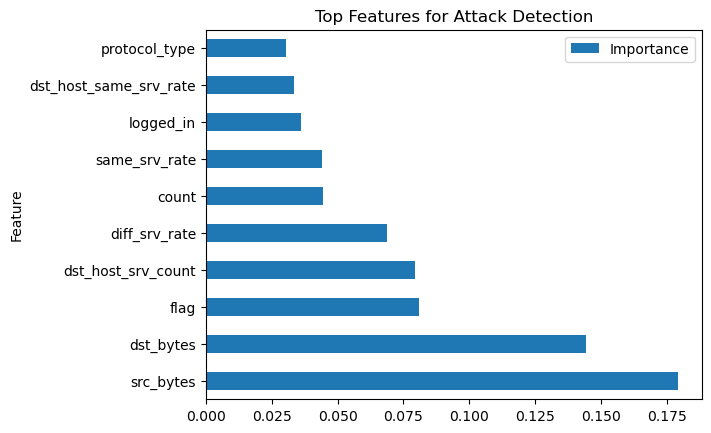

In [46]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top Features for Attack Detection")
plt.show()